In [1]:
!pip install tensorflow tensorflow-datasets


  Using cached protobuf-3.19.6-cp310-cp310-win_amd64.whl.metadata (806 bytes)
INFO: pip is looking at multiple versions of tensorflow-datasets to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of tensorflow-datasets to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of tensorflow-metadata to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of tensorflow-metadata to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of googleapis-common-protos to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of googleapis-common-protos to determine which version is compatible with oth


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip uninstall -y tensorflow-datasets array-record


Found existing installation: tensorflow-datasets 4.9.0
Uninstalling tensorflow-datasets-4.9.0:
  Successfully uninstalled tensorflow-datasets-4.9.0
Found existing installation: array-record 0.4.1
Uninstalling array-record-0.4.1:
  Successfully uninstalled array-record-0.4.1


In [4]:
!pip install array-record==0.4.0
!pip install tensorflow-datasets==4.9.2


   ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
   ------ --------------------------------- 0.5/3.0 MB 5.6 MB/s eta 0:00:01
   ------------- -------------------------- 1.0/3.0 MB 10.1 MB/s eta 0:00:01
   ------------- -------------------------- 1.0/3.0 MB 10.1 MB/s eta 0:00:01
   --------------------------- ------------ 2.1/3.0 MB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 3.0/3.0 MB 3.2 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


^C
  Using cached tensorflow_datasets-4.9.2-py3-none-any.whl.metadata (9.0 kB)
  Using cached protobuf-6.33.2-cp310-abi3-win_amd64.whl.metadata (593 bytes)
  Using cached protobuf-3.20.3-cp310-cp310-win_amd64.whl.metadata (698 bytes)
   ---------------------------------------- 0.0/5.4 MB ? eta -:--:--
   --- ------------------------------------ 0.5/5.4 MB 8.5 MB/s eta 0:00:01
   ------- -------------------------------- 1.0/5.4 MB 10.1 MB/s eta 0:00:01
   --------------- ------------------------ 2.1/5.4 MB 4.3 MB/s eta 0:00:01
   --------------- ------------------------ 2.1/5.4 MB 4.3 MB/s eta 0:00:01
   --------------------- ------------------ 2.9/5.4 MB 2.9 MB/s eta 0:00:01
   ----------------------- ---------------- 3.1/5.4 MB 3.2 MB/s eta 0:00:01
   ----------------------- ---------------- 3.1/5.4 MB 3.2 MB/s eta 0:00:01
   ----------------------- ---------------- 3.1/5.4 MB 3.2 MB/s eta 0:00:01
   ------------------------------- -------- 4.2/5.4 MB 2.4 MB/s eta 0:00:01
   ---------

  You can safely remove it manually.


In [1]:
import tensorflow_datasets as tfds
print("TFDS loaded successfully")


TFDS loaded successfully


In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt


In [3]:
(ds_train, ds_test), ds_info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:]'],
    as_supervised=True,
    with_info=True
)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\nites\tensorflow_datasets\cats_vs_dogs\4.0.0.incompleteACIOVK\cats_vs_dogs-train.tfrecord*.…

Dataset cats_vs_dogs downloaded and prepared to C:\Users\nites\tensorflow_datasets\cats_vs_dogs\4.0.0. Subsequent calls will reuse this data.


In [4]:
IMG_SIZE = 150
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0
    return image, label

train_ds = ds_train.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds  = ds_test.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


C:\Users\nites\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


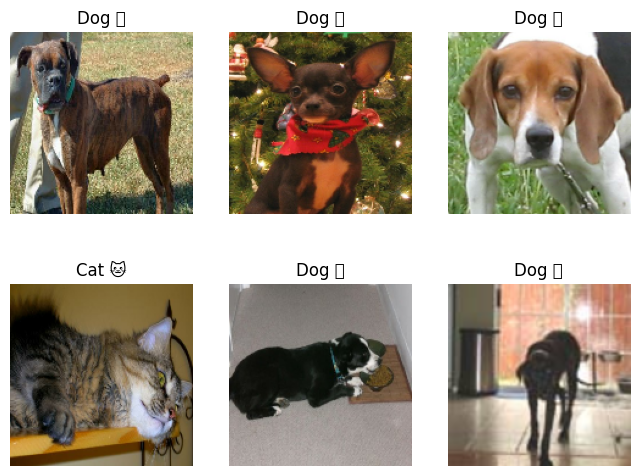

In [5]:
plt.figure(figsize=(8,6))
for images, labels in train_ds.take(1):
    for i in range(6):
        plt.subplot(2,3,i+1)
        plt.imshow(images[i])
        plt.title("Dog 🐶" if labels[i]==1 else "Cat 🐱")
        plt.axis("off")
plt.show()


In [8]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, 3, activation='relu', input_shape=(150,150,3)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])


In [9]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [10]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5
)


Epoch 1/5
582/582 [==============================] - 420s 718ms/step - loss: 0.6164 - accuracy: 0.6532 - val_loss: 0.5405 - val_accuracy: 0.7242
Epoch 2/5
582/582 [==============================] - 413s 709ms/step - loss: 0.4713 - accuracy: 0.7744 - val_loss: 0.4670 - val_accuracy: 0.7728
Epoch 3/5
582/582 [==============================] - 414s 712ms/step - loss: 0.3947 - accuracy: 0.8185 - val_loss: 0.4577 - val_accuracy: 0.7805
Epoch 4/5
582/582 [==============================] - 493s 847ms/step - loss: 0.3128 - accuracy: 0.8667 - val_loss: 0.4806 - val_accuracy: 0.7762
Epoch 5/5
582/582 [==============================] - 467s 802ms/step - loss: 0.2278 - accuracy: 0.9030 - val_loss: 0.5980 - val_accuracy: 0.7779


In [11]:
loss, acc = model.evaluate(test_ds)
print("Test Accuracy:", acc*100, "%")


146/146 [==============================] - 22s 145ms/step - loss: 0.5980 - accuracy: 0.7779
Test Accuracy: 77.79449820518494 %


1/1 [==============================] - 1s 636ms/step


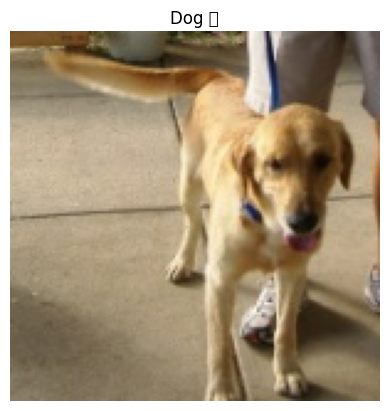

In [12]:
for images, labels in test_ds.take(1):
    pred = model.predict(images)
    plt.imshow(images[0])
    plt.title("Dog 🐶" if pred[0] > 0.5 else "Cat 🐱")
    plt.axis("off")
    plt.show()
